In [1]:
import numpy as np
import sys

from hydro_glasses.delta_kernel import compute_vdos

sys.path.append("../../hydro_glasses")
from hydro_glasses import vibrationalsystem
from hydro_glasses import vibrationalspectra
import matplotlib.pyplot as plt
import time



# VDOS

## Initialize System and Spectra

In [2]:
### Initialize Vibrational System and Spectra

root='aSiO2_648/'
omega_array=np.linspace(0.1,250,10000)
nstoc=10## Number of stochastic vectors
system=vibrationalsystem.VibrationalSystem(root=root)
spectra=vibrationalspectra.\
    VibrationalSpectra(vibrational_system=system, options={'hl_steps':300,'eta':1.0,'omega_array':omega_array}) ### Initialize Vibrational Spectra object

### Compute Stochastic VDOS# of nstoc random vectors
start=time.time()
VDOS=spectra.compute_stochastic_vdos(nstoc=nstoc)
end=time.time()
print('Haydock wall time:{} s'.format(end-start) )

### Plotting
prefactor_error=3

w=spectra.options.omega_array
y=np.mean(np.array([w*VDOS[i]['S'] for i in range(nstoc)]),axis=0)
yerr=prefactor_error*np.std(np.array([w*VDOS[i]['S'] for i in range(nstoc)]),axis=0)/np.sqrt(nstoc)
norm=np.trapz(y, w)
y/=norm
yerr/=norm

#### Compute direct VDOS for comparison
dynmat_dense=spectra.vs.dynmat.toarray()
start=time.time()
w2,eig=np.linalg.eigh(dynmat_dense)
end=time.time()
print('diagonalization time:{} s'.format(end-start) )
eta=spectra.options.eta
w_true=np.sign(w2)*np.sqrt(np.abs(w2))

Number of processes used 10
Haydock wall time:2.6300885677337646 s
diagonalization time:0.7363476753234863 s


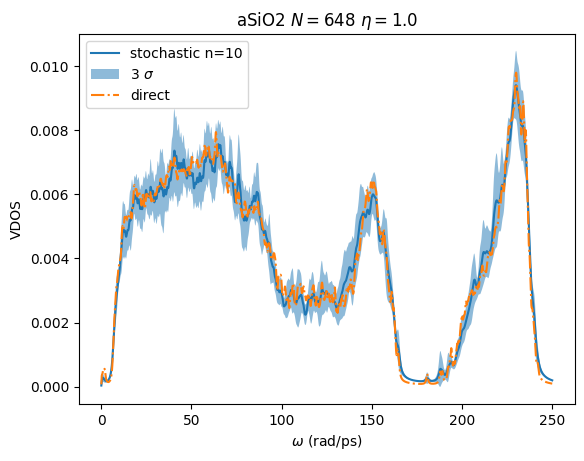

In [3]:
fig,ax=plt.subplots()

ax.plot(w,y,label='stochastic n={}'.format(nstoc))
ax.fill_between(w,y+yerr,y-yerr,alpha=0.5,label=f'{prefactor_error} $\sigma$')

# vdos=compute_vdos(w_true,w,sigma=eta/2,kernel='lorentz')
# ax.plot(w,vdos,'--',label='direct Lor.')
vdos=compute_vdos(w_true,w,sigma=eta,kernel='DHO')
ax.plot(w,vdos,'-.',label='direct') #DHO
chemical_f=spectra.vs.atoms.get_chemical_symbols()[0]
N=spectra.vs.atoms.get_global_number_of_atoms()
plt.title(f'aSiO2 $N={N}$ $\eta={eta}$' )
plt.legend()
plt.ylabel('VDOS')
plt.xlabel('$\omega\mathrm{~(rad/ps)}$')
plt.show()

## VDOS by element

In [4]:
### Compute Stochastic VDOS per element
w=spectra.options.omega_array
VDOS_element={}
for element in ['Si','O']:
    start=time.time()
    VDOS=spectra.compute_stochastic_vdos(nstoc=nstoc,element=element)
    end=time.time()
    print('Haydock wall time:{} s'.format(end-start) )
    y = np.mean(np.array([w * VDOS[i]['S'] for i in range(nstoc)]), axis=0)
    norm=np.trapz(y, w)
    y/=norm
    VDOS_element[element]=y


extracting VDOS for element: %s (experimental feature) Si
Number of processes used 10
Haydock wall time:2.684394121170044 s
extracting VDOS for element: %s (experimental feature) O
Number of processes used 10
Haydock wall time:2.673471212387085 s


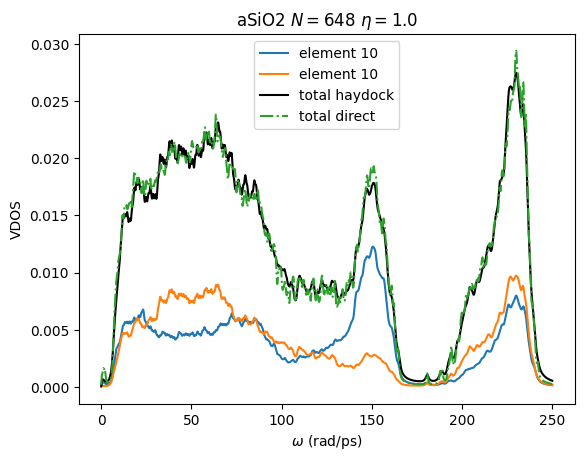

In [5]:
### Plotting
w=spectra.options.omega_array


fig,ax=plt.subplots()
for element in ['Si','O']:
    y=VDOS_element[element]
    ax.plot(w,y,label='element {}'.format(nstoc,element))
tot_vdos=VDOS_element['Si']*1+VDOS_element['O']*2
ax.plot(w,tot_vdos,'-',label='total haydock',color='black')
ax.plot(w,vdos*3,'-.',label='total direct')
plt.title(f'aSiO2 $N={N}$ $\eta={eta}$' )
plt.legend()
plt.ylabel('VDOS')
plt.xlabel('$\omega\mathrm{~(rad/ps)}$')
plt.show()

# IR spectrum

Number of processes used 3
HL wall time in seconds: 2.5251030921936035
(1944,)


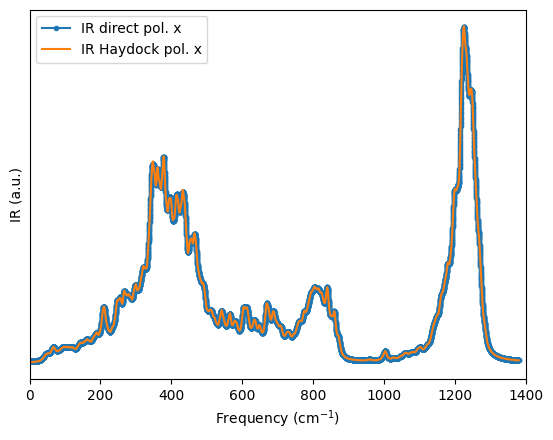

In [6]:
from hydro_glasses.delta_kernel import compute_kernel


root='aSiO2_648/'
omega_array=np.linspace(0.1,260,10000)
system=vibrationalsystem.VibrationalSystem(root=root) ### Read a dynamical matrix and an ASE atoms object
spectra=vibrationalspectra.\
    VibrationalSpectra(vibrational_system=system,options={'hl_steps':300,'eta':1.0,'omega_array':omega_array}) ### Initialize Vibrational Spectra object
start=time.time()
spectrum=spectra.compute_IR_spectrum(polarizations=[0,1,2],charges_dict={'Si':3.2,'O':-1.6})
end=time.time()
print('HL wall time in seconds:',end-start)


thz2cm1=33.35641
# Plotting IR spectrum
###Comparison haydock vs direct method


dynmat_dense=spectra.vs.dynmat.toarray()
w2,eig=np.linalg.eigh(dynmat_dense)

### generate vectors for IR
from hydro_glasses.amorphous_tools import make_IR_vector
atoms=spectra.vs.atoms
phi=make_IR_vector(atoms=atoms,polarizations=[0,1,2],charges_dict={'Si':3.2,'O':-1.6})


w_true=np.sign(w2)*np.sqrt(np.abs(w2))
fig,ax=plt.subplots()
for i, pol in enumerate(['x']):
    #### Here we need the eigenvectors 'eig' and the IR vectors 'phi'
    Z_mu=np.einsum('i,in->n',phi[i],eig)
    print(Z_mu.shape)
    y=np.abs(Z_mu)**2/w_true
    x=spectra.options.omega_array
    y=compute_kernel(w_true, y, x, sigma=spectra.options.eta, kernel='lorentz', normalize=True)
    ax.plot(x*thz2cm1/2/np.pi, y*2*np.pi/thz2cm1, label='IR direct pol. {}'.format(pol),marker='.')
    ### Haydock result
    y=spectrum[i]['S']
    norm=np.trapz(y, x)
    y/=norm
    ax.plot(x*thz2cm1/2/np.pi,y*2*np.pi/thz2cm1,label='IR Haydock pol. {}'.format(pol))
ax.set_xlabel('Frequency (cm$^{-1}$)')
ax.set_ylabel('IR (a.u.)')
ax.set_xlim(0,1400)
ax.set_yticks([])
plt.legend()
plt.show()
